In [1]:
!pip install pandas 
!pip install numpy
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import sklearn as st

In [3]:
df = pd.read_csv(r"spam.csv",encoding="latin-1")
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [7]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2085,ham,Moji i love you more than words. Have a rich day,NaN,NaN,NaN
3071,ham,Ok lor... But buy wat?,NaN,NaN,NaN
4171,ham,"Sorry, I'll call later",NaN,NaN,NaN
5136,ham,There are some nice pubs near here or there is...,NaN,NaN,NaN
1873,spam,You have WON a guaranteed å£1000 cash or a å£2...,NaN,NaN,NaN


In [8]:
df=df.rename(columns={"v1":"spam/ham","v2":"message"})
df

,spam/ham,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [9]:
print(df.duplicated().sum())


403


In [10]:
df=df.drop_duplicates()
df

,spam/ham,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [11]:
df.shape

(5169, 5)

In [12]:

df.isnull().sum
df.isna().sum()


spam/ham         0
message          0
Unnamed: 2    5126
Unnamed: 3    5159
Unnamed: 4    5164
dtype: int64

In [13]:
df=df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"])
df

,spam/ham,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = df["message"]
y = df["spam/ham"] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
model = LogisticRegression()
model.fit(X_train_vec, y_train)

new_message = ["FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send."]
new_message_vec = vectorizer.transform(new_message)
prediction = model.predict(new_message_vec)

print(prediction[0])


ham


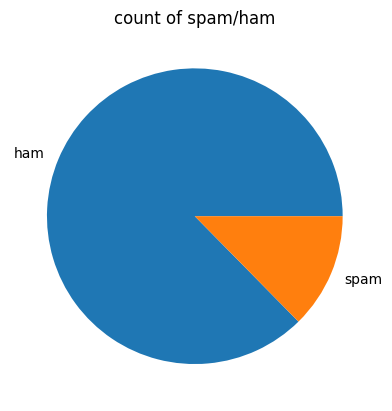

None


In [15]:
import matplotlib.pyplot as plt
df1=df["spam/ham"].value_counts()
plt.title("count of spam/ham")
lables=["spam","ham"]
pieData=plt.pie(df1,labels=df1.index)
print(plt.show())

In [16]:
print(df["spam/ham"].value_counts())

spam/ham
ham     4516
spam     653
Name: count, dtype: int64


In [17]:
!pip install nltk
import nltk


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import nltk

nltk.download("punkt")
nltk.download("wordnet")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bhawana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Bhawana\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bhawana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
df["count_character"] = df["message"].apply(len)
df

,spam/ham,message,count_character
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [20]:
df["word_counts"] = df["message"].apply(lambda x:len(nltk.word_tokenize(x)))
df

,spam/ham,message,count_character,word_counts
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35
5568,ham,Will Ì_ b going to esplanade fr home?,37,9
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15
5570,ham,The guy did some bitching but I acted like i'd...,125,27


In [21]:
df["num_sentence"] = df['message'].apply(lambda x:len(nltk.word_tokenize(x)))
df

,spam/ham,message,count_character,word_counts,num_sentence
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,24
1,ham,Ok lar... Joking wif u oni...,29,8,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,37
3,ham,U dun say so early hor... U c already then say...,49,13,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,15
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,35
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,9
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,15
5570,ham,The guy did some bitching but I acted like i'd...,125,27,27


In [22]:
df["true/false"] = df["spam/ham"].map({"ham": 0, "spam": 1})
print(df)

     spam/ham                                            message  \
0         ham  Go until jurong point, crazy.. Available only ...   
1         ham                      Ok lar... Joking wif u oni...   
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3         ham  U dun say so early hor... U c already then say...   
4         ham  Nah I don't think he goes to usf, he lives aro...   
...       ...                                                ...   
5567     spam  This is the 2nd time we have tried 2 contact u...   
5568      ham              Will Ì_ b going to esplanade fr home?   
5569      ham  Pity, * was in mood for that. So...any other s...   
5570      ham  The guy did some bitching but I acted like i'd...   
5571      ham                         Rofl. Its true to its name   

      count_character  word_counts  num_sentence  true/false  
0                 111           24            24           0  
1                  29            8             8         

In [23]:
print(df["true/false"].value_counts())

true/false
0    4516
1     653
Name: count, dtype: int64


In [24]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='word_counts', ylabel='Count'>

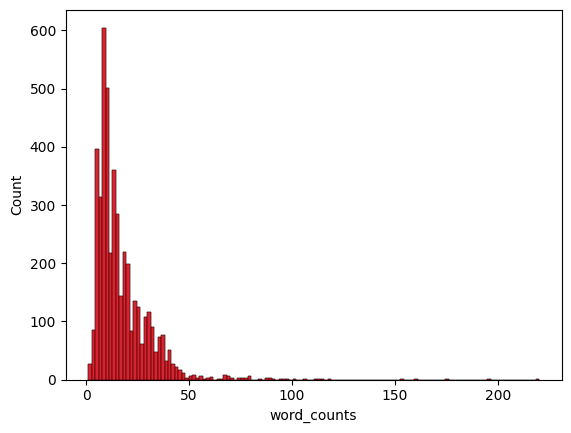

In [25]:
import seaborn as sns
sns.histplot(df[df["true/false"]==0]["word_counts"])
sns.histplot(df[df["true/false"]==0]["word_counts"], color="red")

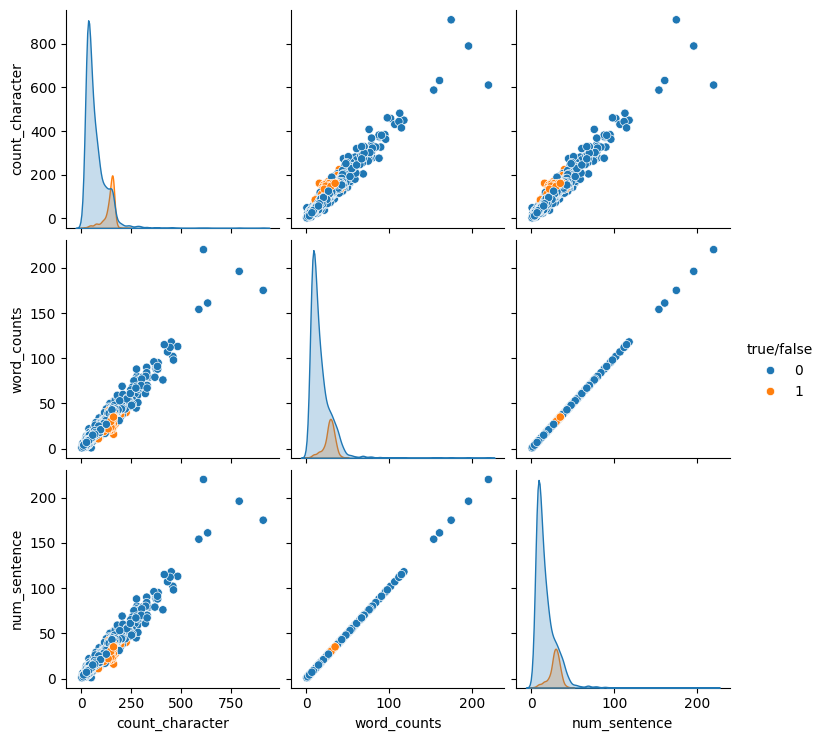

In [26]:
sns.pairplot(df, hue="true/false")

In [27]:
#Data Preprocessing
#Lower case
#Tokenization
#Remove spetial char
#remove stop word (puctuation) --> jo sentence making m kaam aata h 
#Stemming--> stop , stopping , text ,texting

In [28]:
import string
import nltk
from nltk.stem import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bhawana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:


ps = PorterStemmer()

def data_preprocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []                       # Initialize list

    # Remove non-alphanumeric words
    for i in text:
        if i.isalnum():
            y.append(i)

    # Remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [30]:
text = "This is the @#a6, BHAWANA!! stop stopping"
data_preprocessing(text)

'thi is the a6 bhawana stop stop a6 bhawana stop stop'

In [31]:
df

,spam/ham,message,count_character,word_counts,num_sentence,true/false
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,24,0
1,ham,Ok lar... Joking wif u oni...,29,8,8,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,37,1
3,ham,U dun say so early hor... U c already then say...,49,13,13,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,15,0
...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,35,1
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,9,0
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,15,0
5570,ham,The guy did some bitching but I acted like i'd...,125,27,27,0


In [32]:
df["transformed_message"] = df["message"].apply(data_preprocessing)
df

,spam/ham,message,count_character,word_counts,num_sentence,true/false,transformed_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,24,0,go until jurong point crazi avail onli in bugi...
1,ham,Ok lar... Joking wif u oni...,29,8,8,0,ok lar joke wif u oni ok lar ... joke wif u on...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,37,1,free entri in 2 a wkli comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,13,13,0,u dun say so earli hor u c alreadi then say u ...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,15,0,nah i do think he goe to usf he live around he...
...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,35,1,thi is the 2nd time we have tri 2 contact u ha...
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,9,0,will b go to esplanad fr home ì_ b go esplanad...
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,15,0,piti wa in mood for that so ani other suggest ...
5570,ham,The guy did some bitching but I acted like i'd...,125,27,27,0,the guy did some bitch but i act like i be int...


In [33]:
!pip install WordCloud


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from wordcloud import WordCloud
wc = WordCloud(min_font_size=10,background_color='white')

In [35]:
df

,spam/ham,message,count_character,word_counts,num_sentence,true/false,transformed_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,24,0,go until jurong point crazi avail onli in bugi...
1,ham,Ok lar... Joking wif u oni...,29,8,8,0,ok lar joke wif u oni ok lar ... joke wif u on...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,37,1,free entri in 2 a wkli comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,13,13,0,u dun say so earli hor u c alreadi then say u ...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,15,0,nah i do think he goe to usf he live around he...
...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,35,1,thi is the 2nd time we have tri 2 contact u ha...
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,9,0,will b go to esplanad fr home ì_ b go esplanad...
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,15,0,piti wa in mood for that so ani other suggest ...
5570,ham,The guy did some bitching but I acted like i'd...,125,27,27,0,the guy did some bitch but i act like i be int...


In [36]:
print(df["spam/ham"].value_counts())

spam/ham
ham     4516
spam     653
Name: count, dtype: int64


In [37]:
print(df[["spam/ham", "transformed_message"]].head(10))

  spam/ham                                transformed_message
0      ham  go until jurong point crazi avail onli in bugi...
1      ham  ok lar joke wif u oni ok lar ... joke wif u on...
2     spam  free entri in 2 a wkli comp to win fa cup fina...
3      ham  u dun say so earli hor u c alreadi then say u ...
4      ham  nah i do think he goe to usf he live around he...
5     spam  freemsg hey there darl it been 3 week now and ...
6      ham  even my brother is not like to speak with me t...
7      ham  as per your request mell oru minnaminungint nu...
8     spam  winner as a valu network custom you have been ...
9     spam  had your mobil 11 month or more u r entitl to ...


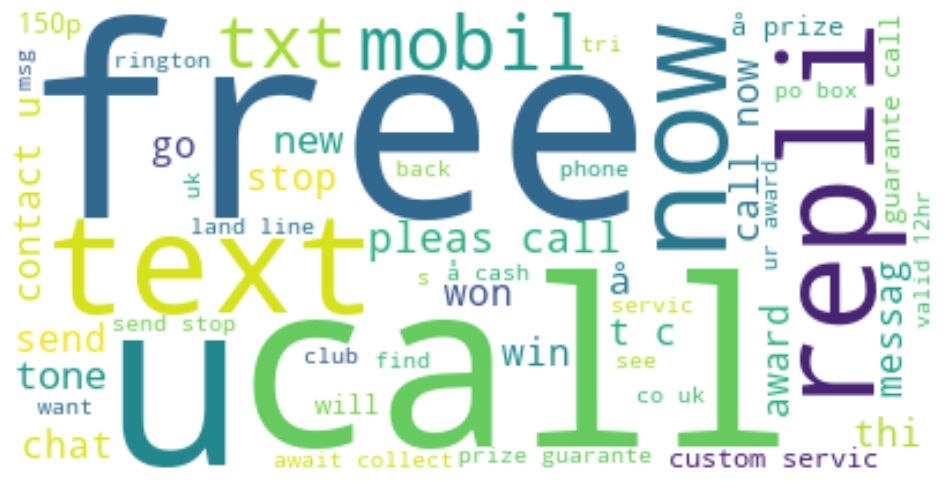

In [38]:
# Combine all spam messages into one string
spam_text = df[df["spam/ham"] == "spam"]["transformed_message"].dropna().str.cat(sep=" ")

# Check if there is any text
if spam_text.strip():
    spam_wc = wc.generate(spam_text)

    plt.figure(figsize=(15, 6))
    plt.imshow(spam_wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
else:
    print("No spam text available to generate a word cloud.")

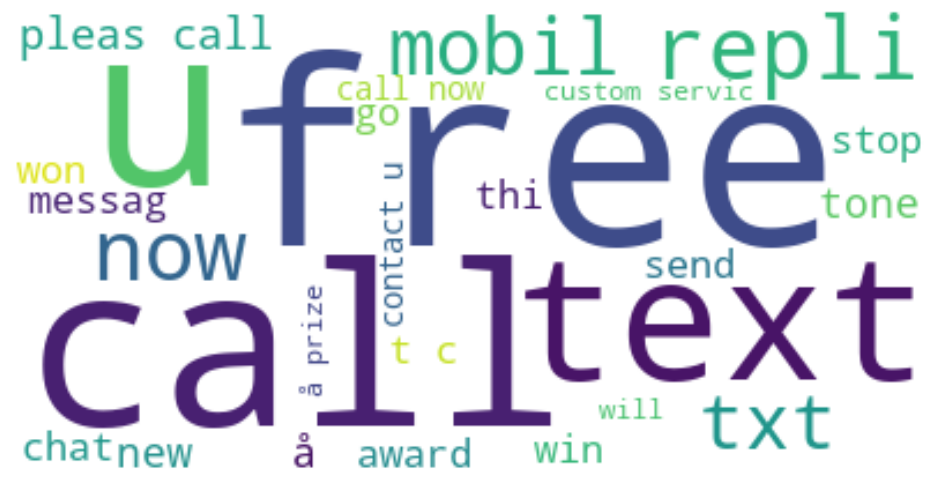

In [39]:
# Combine all spam messages into one string
ham_text = df[df["spam/ham"] == "spam"]["transformed_message"].dropna().str.cat(sep=" ")

# Check if there is any text
if ham_text.strip():
    ham_wc = wc.generate(spam_text)

    plt.figure(figsize=(15, 6))
    plt.imshow(ham_wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
else:
    print("No spam text available to generate a word cloud.")
    

In [40]:
spam_corpus = []
for i in df[df["true/false"] == 1]["transformed_message"].tolist():
    for word in i.split():
        spam_corpus.append(i)



In [41]:
ham_corpus = []
for i in df[df["true/false"] == 0]["transformed_message"].tolist():
    for word in i.split():
        ham_corpus.append(i)

In [42]:
len(spam_corpus)

25558

In [43]:
len(ham_corpus)

102706

In [44]:
spam_corpus = []
for msj in df[df["true/false"] == 1]["transformed_message"].tolist():
    for word in msj.split():
        spam_corpus.append(word)

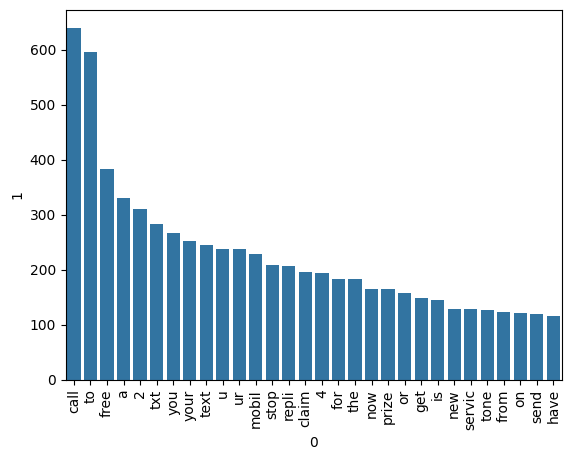

In [45]:
from collections import Counter

sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [46]:
ham_corpus = []
for msj in df[df["true/false"] == 0]["transformed_message"].tolist():
    for word in msj.split():
        ham_corpus.append(word)


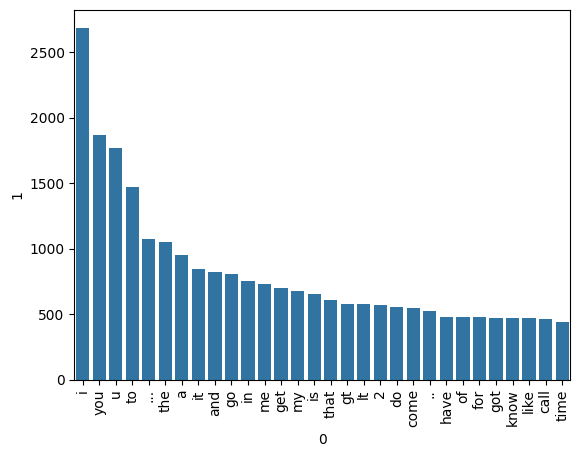

In [47]:
from collections import Counter

sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [48]:
#model building 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [49]:
X= tfidf.fit_transform(df["transformed_message"]).toarray()

In [50]:
X.shape

(5169, 3000)

In [51]:
Y = df["true/false"].values

In [52]:
from sklearn.model_selection  import train_test_split 
X_train, X_test , Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [53]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score

In [54]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [55]:
gnb.fit(X_train, Y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(Y_test,y_pred1))
print(confusion_matrix(Y_test,y_pred1))
print(precision_score(Y_test,y_pred1))

0.8810444874274661
[[796 100]
 [ 23 115]]
0.5348837209302325


In [56]:
mnb.fit(X_train, Y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(Y_test,y_pred1))
print(confusion_matrix(Y_test,y_pred1))
print(precision_score(Y_test,y_pred1))

0.9758220502901354
[[896   0]
 [ 25 113]]
1.0


In [57]:
bnb.fit(X_train, Y_train)
y_pred1 = bnb.predict(X_test)
print(accuracy_score(Y_test,y_pred1))
print(confusion_matrix(Y_test,y_pred1))
print(precision_score(Y_test,y_pred1))

0.9845261121856866
[[893   3]
 [ 13 125]]
0.9765625
